# InhibitorCNN — Training

Classifies hand-drawn sketches into three drug-discovery outcome classes:

| Class | Label | QuickDraw shape | Meaning |
|-------|-------|-----------------|---------|
| 0 | **Selective** | square | Hits the target selectively — the ideal outcome |
| 1 | **Toxic** | triangle | Off-target toxicity — active but harmful |
| 2 | **Inactive** | circle / star / zigzag / line / cloud | No meaningful activity |

The model is a lightweight CNN (~120 k params) trained on 28×28 QuickDraw bitmaps.

## Config

In [1]:
from pathlib import Path

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from tqdm.notebook import tqdm

from dataset import QuickDrawDataset
from model import InhibitorCNN

DATA_DIR = Path.cwd() / "data"
CKPT_DIR = Path.cwd() / "checkpoints"

SAMPLES_PER_CLASS = 10_000
BATCH_SIZE        = 128
EPOCHS            = 25
LR                = 1e-3
WEIGHT_DECAY      = 1e-4
NUM_WORKERS       = 4

CLASS_NAMES = ["Selective (square)", "Toxic (triangle)", "Inactive (other)"]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cpu


## Dataset

85 % of each class goes to train, 15 % to val.  
Training split gets random affine, perspective, blur and noise augmentation.

Train: 25,500  |  Val: 4,500


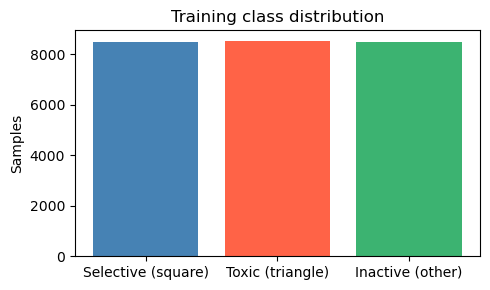

In [2]:
import numpy as np
import matplotlib.pyplot as plt

train_ds = QuickDrawDataset(DATA_DIR, split="train", samples_per_class=SAMPLES_PER_CLASS)
val_ds   = QuickDrawDataset(DATA_DIR, split="val",   samples_per_class=SAMPLES_PER_CLASS)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

print(f"Train: {len(train_ds):,}  |  Val: {len(val_ds):,}")

# Class balance
counts = np.bincount(train_ds.labels)
fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(CLASS_NAMES, counts, color=["steelblue", "tomato", "mediumseagreen"])
ax.set_ylabel("Samples")
ax.set_title("Training class distribution")
plt.tight_layout()
plt.show()

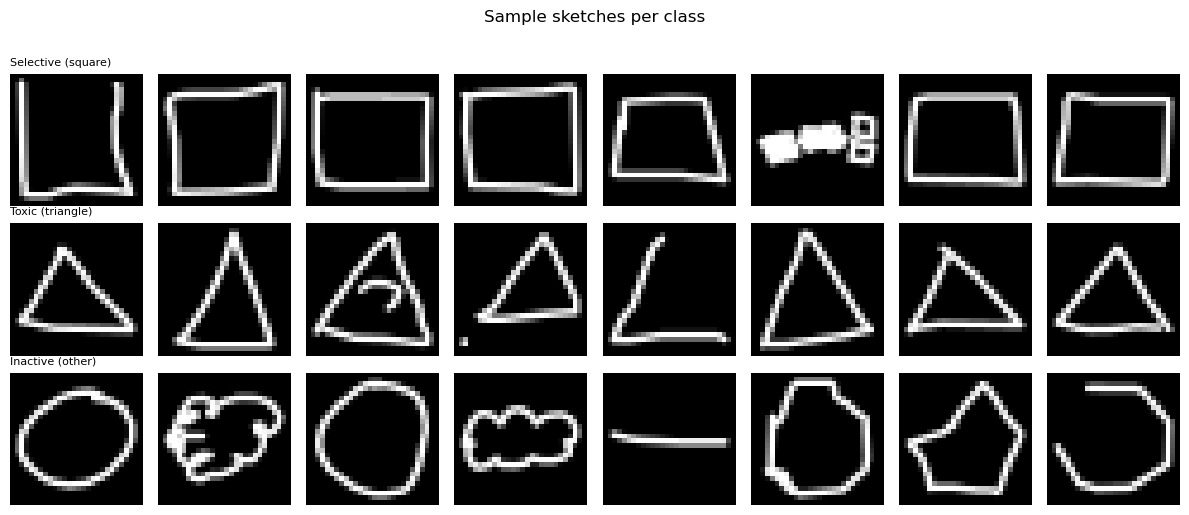

In [3]:
# Visualise a few examples per class
fig, axes = plt.subplots(3, 8, figsize=(12, 5))
for cls in range(3):
    idx = np.where(train_ds.labels == cls)[0][:8]
    for col, i in enumerate(idx):
        img = train_ds.images[i].reshape(28, 28)
        axes[cls, col].imshow(img, cmap="gray")
        axes[cls, col].axis("off")
        if col == 0:
            axes[cls, col].set_title(CLASS_NAMES[cls], loc="left", fontsize=8)
plt.suptitle("Sample sketches per class", y=1.02)
plt.tight_layout()
plt.show()

## Model

In [4]:
model = InhibitorCNN(num_classes=3).to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f"Parameters: {n_params:,}")
print(model)

Parameters: 389,059
InhibitorCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU()
  )
  (pool): AdaptiveAvgPool2d(output_size=3)
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1152, out_features=256, bias=True)
    (2): ReLU()
 

## Training

In [5]:
from tqdm import tqdm
def accuracy(logits, labels):
    return (logits.argmax(dim=1) == labels).float().mean().item()


def run_epoch(model, loader, criterion, optimizer, train: bool):
    model.train(train)
    total_loss, total_acc, n = 0.0, 0.0, 0
    with torch.set_grad_enabled(train):
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            logits = model(imgs)
            loss = criterion(logits, labels)
            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            bs = len(labels)
            total_loss += loss.item() * bs
            total_acc  += accuracy(logits, labels) * bs
            n += bs
    return total_loss / n, total_acc / n


criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

CKPT_DIR.mkdir(parents=True, exist_ok=True)
best_val_acc = 0.0
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

for epoch in tqdm(range(1, EPOCHS + 1), desc="Epochs"):
    train_loss, train_acc = run_epoch(model, train_loader, criterion, optimizer, train=True)
    val_loss,   val_acc   = run_epoch(model, val_loader,   criterion, optimizer, train=False)
    scheduler.step()

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    flag = ""
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), CKPT_DIR / "best_model.pt")
        flag = "  ← best"

    print(
        f"Epoch {epoch:>2}/{EPOCHS} | "
        f"train loss {train_loss:.4f} acc {train_acc:.3f} | "
        f"val loss {val_loss:.4f} acc {val_acc:.3f}{flag}"
    )

print(f"\nBest val accuracy: {best_val_acc:.3f}")
print(f"Checkpoint: {CKPT_DIR / 'best_model.pt'}")

Epochs:   4%|▍         | 1/25 [00:23<09:14, 23.09s/it]

Epoch  1/25 | train loss 0.5307 acc 0.789 | val loss 0.2637 acc 0.913  ← best


Epochs:   8%|▊         | 2/25 [00:46<08:48, 22.99s/it]

Epoch  2/25 | train loss 0.2300 acc 0.923 | val loss 0.3221 acc 0.907


Epochs:  12%|█▏        | 3/25 [01:08<08:23, 22.91s/it]

...

Epoch 23/25 | train loss 0.1013 acc 0.969 | val loss 0.1071 acc 0.972  ← best


Epochs:  96%|█████████▌| 24/25 [09:06<00:22, 22.74s/it]

Epoch 24/25 | train loss 0.0990 acc 0.969 | val loss 0.1091 acc 0.971


Epochs: 100%|██████████| 25/25 [09:29<00:00, 22.78s/it]

Epoch 25/25 | train loss 0.1023 acc 0.968 | val loss 0.1066 acc 0.971

Best val accuracy: 0.972
Checkpoint: /home/sbnb/ddalton/git_clones/openday26/ml/checkpoints/best_model.pt


## Results

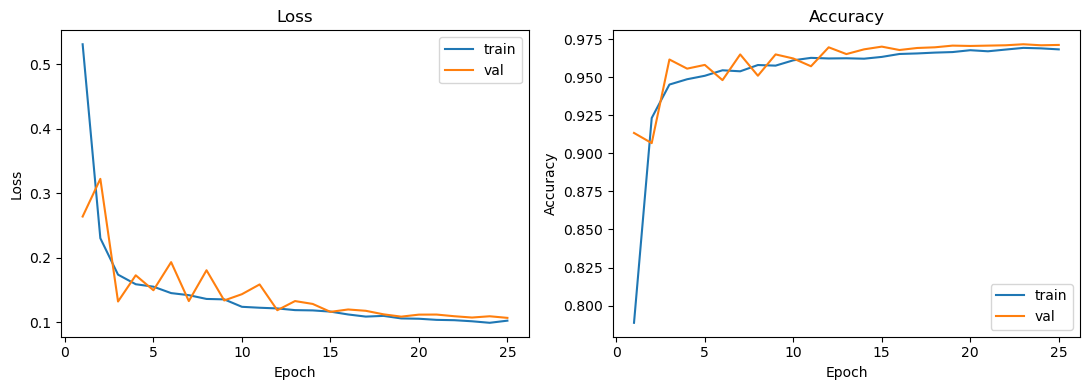

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

epochs = range(1, EPOCHS + 1)
ax1.plot(epochs, history["train_loss"], label="train")
ax1.plot(epochs, history["val_loss"],   label="val")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss"); ax1.set_title("Loss")
ax1.legend()

ax2.plot(epochs, history["train_acc"], label="train")
ax2.plot(epochs, history["val_acc"],   label="val")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy"); ax2.set_title("Accuracy")
ax2.legend()

plt.tight_layout()
plt.show()

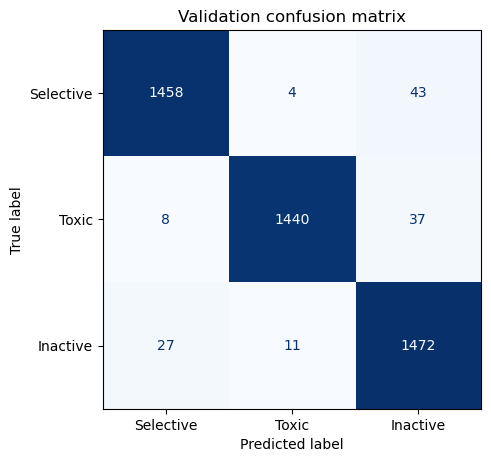

In [7]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in val_loader:
        preds = model(imgs.to(device)).argmax(dim=1).cpu()
        all_preds.append(preds)
        all_labels.append(labels)

all_preds  = torch.cat(all_preds).numpy()
all_labels = torch.cat(all_labels).numpy()

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=["Selective", "Toxic", "Inactive"])
fig, ax = plt.subplots(figsize=(5, 5))
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Validation confusion matrix")
plt.tight_layout()
plt.show()